# Trendlines

In [28]:
import yfinance as yf
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [1]:
# load data
t = yf.download(
    "AAPL",
    start = "1960-01-01",  
    end = "2025-08-31", 
    auto_adjust = True
    )

# restructure data
t = t.droplevel(level='Ticker', axis=1)

# rename columns
t.rename(
    columns = {
        'Open':'o', 
        'High':'h', 
        'Low':'l', 
        'Close':'c', 
        'Volume':'v'
    }, 
    inplace = True)

[*********************100%***********************]  1 of 1 completed


Let us check how well minimization of distances work.

* Take N days.
* For high prices find a line that is above them and minimize the total distance.
* For low prices find a line that is blood them and also minimizes the total distance.

In [96]:
def get_intervs(ys):
    n = len(ys)
    xs = np.arange(n)*1.0

    intervs = []
    i = 0
    while True:
        rs = []
        for j in range(i+1, n):
            x1, y1 = xs[i], ys[i]
            x2, y2 = xs[j], ys[j]
            r = (y2 - y1)/(x2 - x1)
            rs.append((r,j))
        rs.sort()
        j_max = rs[-1][1]
        x2, y2 = xs[j_max], ys[j_max]
        intervs.append(([x1,x2],[y1,y2]))
        if j_max == n - 1:
            return intervs
        i = j_max
    return intervs        

In [147]:
k = 7510
wind = 15
tmp = t[k:k+wind]
hs = tmp.h.values
ls = tmp.l.values

intervs_h = get_intervs(hs)
intervs_l = get_intervs(-ls)

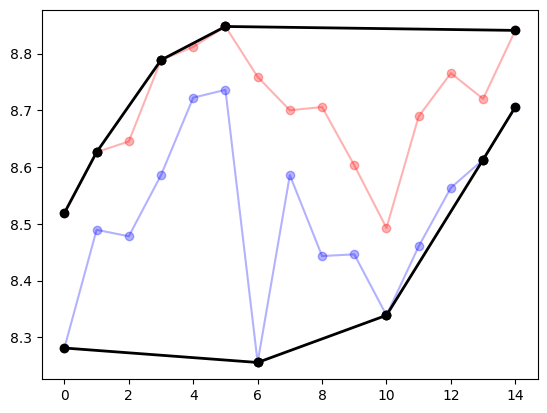

In [148]:
plt.plot(hs, marker = 'o', color = 'r', alpha = 0.3)
plt.plot(ls, marker = 'o', color = 'b', alpha = 0.3)

for xs, ys in intervs_h:
    plt.plot(xs, ys, color = 'k', alpha = 1.0, linewidth = 2, marker = 'o')

for xs, ys in intervs_l:
    plt.plot(xs, -np.array(ys), color = 'k', alpha = 1.0, linewidth = 2, marker = 'o')

In [64]:
class LineQuality:

    def __init__(self, vals, is_above):
        self.vals = np.array(vals)
        self.is_above = is_above

    def get_costs(self, params):
        n = len(self.vals)
        xs = np.arange(n)*1.0
        ys = params[0] + params[1]*xs
        if self.is_above:
            dists = ys - self.vals
        else:
            dists = self.vals - ys
        penalty = -1.0 * pow(10.0, 6)
        self.costs = np.where(dists >= 0.0, dists, dists*penalty)
        out = np.sum(self.costs)
        #print(out)
        return out

In [65]:
k = 100
wind = 10
tmp = t[k:k+wind]
hs = tmp.h.values

lq = LineQuality(hs, True)

In [66]:
lq.get_costs([0.5, 0.3])

17.546407653691116

In [41]:
lq.costs

array([95487.69279102, 96344.03273617, 94203.16217356, 95059.49884191,
       94631.33461008, 92918.66848234, 95487.69724243, 96772.19261049,
       94631.36033008, 98056.70649081])

In [57]:
ini = [np.mean(hs), 0.0]
result = minimize(lq.get_costs, ini)

5352.154068630745
5352.079562899282
5351.811342251112
46.55820514609842
46.558205295110035
46.55820581665068
46.5129876089106
46.51298775792221
46.51298827946285
823529.9200774465
823529.9051764194
823529.920078117
46.512987598937556
46.51298774794917
46.51298826948981
46.51298758896453
46.51298773797614
46.51298825951678
408366.34585921414
408366.33095818706
408366.3458598847
46.5129875839148
46.51298773292641
46.512988254467054
46.512987578865065
46.51298772787668
46.51298824941732
200784.58193207122
200784.56703104413
200784.58193274177
46.512987576274526
46.51298772528614
46.51298824682678
46.51298757368398
46.51298772269559
46.51298824423623
96993.7118609984
96993.69695997132
96993.71186166895
46.512987572317634
46.512987721329246
46.51298824286989
46.51298757095127
46.51298771996288
46.51298824150352
45098.2830980448
45098.268197017715
45098.28309871535
46.51298757018387
46.51298771919548
46.51298824073612
46.51298756941645
46.512987718428064
46.512988239968706
19150.57223954575


In [58]:
result 

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 46.55820514609842
        x: [ 3.099e-01  9.869e-01]
      nit: 1
      jac: [ 1.000e+01  4.500e+01]
 hess_inv: [[ 9.549e-01 -2.076e-01]
            [-2.076e-01  4.513e-02]]
     nfev: 255
     njev: 82

In [83]:
#best_costs = None
for i in range(10_000_000):
    params = np.random.normal(size = 2)
    costs = lq.get_costs(params)
    if best_costs == None or costs < best_costs:
        best_costs = costs
        best_params = params.copy()
        print(i, best_costs, best_params)

32205 0.023176710158717778 [0.09629552 0.00030697]


In [84]:
xs = np.arange(10)
#ys = result.x[0] + result.x[1]*xs
ys = best_params[0] + best_params[1]*xs

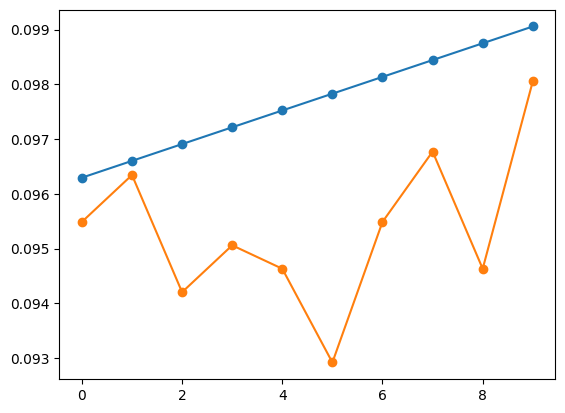

In [85]:
plt.plot(xs, ys, marker = 'o')
plt.plot(xs, hs, marker = 'o')

We need a custom optimization.
